<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks%20/14_LogisticRegression_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression으로 테슬라(TSLA) 다음 거래일 상승·하락 예측

이 노트북은 주가 수준이 아니라 **거래일 t의 장 마감 정보를 이용하여 거래일 t+1의 종가 상승 여부**를 예측합니다.

- `1`: 다음 거래일 종가가 오늘 종가보다 높음
- `0`: 다음 거래일 종가가 오늘 종가보다 높지 않음(하락 또는 보합)
- **시간순 분할**, **예측시점에서 이용 가능한 정보**, **Naïve/다수 클래스 기준모형**과의 비교가 핵심입니다.
- 결과는 방향성 예측 실습용이며, 실제 매매 수익이나 인과관계를 입증하지 않습니다.

## 0) 환경 준비
Colab의 코드 셀에서 `!pip -q install yfinance`를 실행할 수 있습니다. 설치가 필요한 경우에만 사용하세요.

이 노트북은 영어로 그래프를 출력해 Colab의 한글 글꼴 깨짐을 방지합니다.

In [1]:
import numpy as np
import pandas as pd
# Colab에 yfinance가 없으면 자동 설치 (기존 셀 구조 유지)
try:
    import yfinance as yf
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', 'yfinance'])
    import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# 흰색 배경으로 출력하고 매번 동일한 그래프 스타일 사용
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

## 1) 데이터 수집
- 원본과 동일한 기간: **2025-03-30 ~ 2026-03-30** (`end`는 미포함)
- `auto_adjust=True`: 수정주가로 일별 변동을 계산
- `yfinance` 버전에 따라 발생하는 MultiIndex 열을 단일 열로 정리

**예측 시점**: 거래일 t의 종가가 확인된 뒤, 다음 거래일 t+1의 상승 여부를 예측합니다.

In [2]:
# 2025-03-30부터 2026-03-29까지의 TSLA 데이터를 다운로드합니다.
raw = yf.download('TSLA', start='2025-03-30', end='2026-03-30',
                  auto_adjust=True, progress=False)
if raw.empty:
    raise ValueError('TSLA 다운로드 결과가 비어 있습니다. 인터넷 연결과 조회기간을 확인하세요.')

# 일부 yfinance 버전은 ('Close', 'TSLA') 형태의 MultiIndex를 반환합니다.
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# 날짜 및 종가를 사용할 수 있도록 데이터프레임 구조 정리
df = raw.reset_index().copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)
print(df[['Date', 'Close']].head())
print('Rows:', len(df))

Price       Date       Close
0     2025-03-31  259.160004
1     2025-04-01  268.459991
2     2025-04-02  282.760010
3     2025-04-03  267.279999
4     2025-04-04  239.429993
Rows: 250


## 2) 특징(Feature) 생성

거래일 t의 장 마감 직후 다음 거래일 t+1을 예측하므로, **t까지 관측 가능한 값**은 사용할 수 있습니다.

- `ret_lag1`~`ret_lag10`: 과거 1·2·3·5·10거래일 전의 수익률
- `ma_gap`: 거래일 t까지 관측한 5일 및 20일 이동평균 간 이격도
- `vol10`: 거래일 t까지 관측한 최근 10일 수익률의 표준편차
- `ret1`: 당일 수익률(모멘텀 기준모형에서만 사용)

**주의**: `ma_gap`과 `vol10`은 당일 종가를 포함하지만, 오늘 장 마감 *후* 내일을 예측하는 설계이므로 누수가 아닙니다. 오늘 장 마감 *전*에 예측한다면 한 시점 늦춰야 합니다.

In [3]:
# t 시점 종가가 확정된 뒤 t+1의 방향을 예측합니다.
df['ret1'] = df['Close'].pct_change()  # 오늘 종가/어제 종가 - 1

# t를 기준으로 1, 2, 3, 5, 10거래일 전의 수익률
for k in [1, 2, 3, 5, 10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

# 오늘 종가까지 포함한 이동평균: 내일 예측에 사용 가능
df['ma5'] = df['Close'].rolling(window=5).mean()
df['ma20'] = df['Close'].rolling(window=20).mean()
df['ma_gap'] = df['ma5'] / df['ma20'] - 1.0

# 최근 10거래일 수익률 표준편차(오늘까지 관측한 정보)
df['vol10'] = df['ret1'].rolling(window=10).std()

# 초기 이동평균·시차로 발생한 NaN만 제거 (미래 데이터로 보간하지 않음)
df = df.dropna(subset=['ret1', 'ret_lag1', 'ret_lag2', 'ret_lag3',
                       'ret_lag5', 'ret_lag10', 'ma_gap', 'vol10']).reset_index(drop=True)
print('After feature engineering rows:', len(df))

After feature engineering rows: 231


## 3) 타깃 정의
### (A) 이진 분류(상승/하락)
- `y_bin = 1` if 내일 종가가 오늘보다 상승, else 0

### (B) 다중 분류(상승/보합/하락)
- 작은 변동은 ‘보합(0)’로 두고, 상승(+1)/하락(-1) 3클래스로 구성할 수 있습니다.
- 예: 임계치 `thr=0.002`(0.2%)

수업/실습에서는 먼저 (A) 이진부터 안정적으로 돌린 뒤, (B)를 확장하는 것을 권장합니다.


In [4]:
# 다음 거래일 수익률: (t+1 종가 / t 종가) - 1
df['ret_next'] = df['Close'].shift(-1) / df['Close'] - 1.0

# 마지막 날에는 다음 거래일 정답을 알 수 없으므로 라벨 생성 전에 제거합니다.
df = df.dropna(subset=['ret_next']).reset_index(drop=True)

# 0 = 하락 또는 보합, 1 = 상승 (동일 종가는 0으로 분류)
df['y_bin'] = (df['ret_next'] > 0).astype(int)

# 선택 실습: -1 하락, 0 보합, +1 상승 (0.2% 기준은 사전에 고정)
thr = 0.002
df['y_multi'] = np.where(df['ret_next'] > thr, 1,
                  np.where(df['ret_next'] < -thr, -1, 0))
print(df[['Date', 'Close', 'ret_next', 'y_bin', 'y_multi']].head())

Price       Date       Close  ret_next  y_bin  y_multi
0     2025-04-28  285.880005  0.021513      1        1
1     2025-04-29  292.029999 -0.033798      0       -1
2     2025-04-30  282.160004 -0.005812      0       -1
3     2025-05-01  280.519989  0.023849      1        1
4     2025-05-02  287.209991 -0.024198      0       -1


## 4) 학습·테스트 분할 (시간 순서 보존)
- 데이터의 마지막 20%를 외표본(Test)으로 분리합니다.
- 다음날 수익률을 예측하므로 학습 마지막 행의 정답이 **테스트 시작일 종가**를 참조하지 않도록 경계 1개 관측치를 제외합니다(Purge).
- `C=1.0` 및 임계값 0.5는 **사전 고정**하며 테스트 데이터로 튜닝하지 않습니다.
- `StandardScaler`는 Pipeline 안에서 **학습 구간에만 fit**합니다.

In [5]:
features = ['ret_lag1', 'ret_lag2', 'ret_lag3',
            'ret_lag5', 'ret_lag10', 'ma_gap', 'vol10']
X = df[features]
y = df['y_bin']

# 시계열은 과거 80% / 최근 20% 순서로 분리합니다.
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
y_train, y_test = y.iloc[:split].copy(), y.iloc[split:].copy()

# 학습 경계의 마지막 행은 바로 다음(테스트 첫날) 종가를 정답에 사용하므로 제외.
X_train, y_train = X_train.iloc[:-1], y_train.iloc[:-1]
if len(X_train) < 30 or len(X_test) < 10 or y_train.nunique() < 2:
    raise ValueError('학습/평가 표본이 부족하거나 학습 라벨이 한 종류입니다. 조회기간을 늘려주세요.')

# 인덱스와 날짜의 정렬을 그대로 유지한 채로 평가에 사용합니다.
test_dates = df.loc[X_test.index, 'Date']
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train through:', df.loc[X_train.index[-1], 'Date'].date())
print('Test from:', test_dates.iloc[0].date())

Train: (183, 7) Test: (46, 7)
Train through: 2026-01-16
Test from: 2026-01-21


### 🔍 피처(Feature) 상세 설명

1. **과거 수익률 `ret_lag1`~`ret_lag10`**: 오늘(t)을 기준으로 1, 2, 3, 5, 10거래일 전에 관측된 일별 수익률입니다. 단기 모멘텀·반전을 설명하는 후보입니다.
2. **이동평균 이격도 `ma_gap`**: `(MA_5 / MA_20) - 1`이며, 두 이동평균 모두 오늘(t)까지의 종가를 사용합니다. 다음 거래일을 예측하기 때문에 사용 가능합니다.
3. **변동성 `vol10`**: 오늘(t)까지 최근 10일 수익률의 표준편차입니다. 변동성이 큰 시장과 작은 시장에서 방향성 예측이 달라지는지 탐색합니다.

이 변수들은 **예측변수**이며, 통계적·인과적 영향이 입증되었다는 의미는 아닙니다. 데이터의 특성에 따라 예측력은 없을 수도 있습니다.

## 5) 모델: Logistic Regression (확률 분류기)

다음 거래일 상승 확률을 계산합니다.

$$
P(Y=1\mid X)=\frac{1}{1+\exp(-z)}
$$

$$
z=\beta_0+\sum_{j=1}^{p}\beta_j X_j
$$

- 모델이 출력한 확률이 0.5 이상이면 상승(1)으로 분류합니다.
- `StandardScaler`: 학습 데이터 평균·표준편차로 변수를 표준화합니다.
- `C=1.0`: L2 규제의 역강도입니다. 작은 C는 더 강한 규제를 뜻합니다.
- 학습 시점에 알려진 데이터만 사용하며 결과는 인과효과가 아닙니다.

In [6]:
# 5) 모델 구축과 학습: scaler와 분류기를 반드시 하나의 Pipeline으로 묶습니다.
# fit(X_train, y_train) 수행 시 StandardScaler도 학습 데이터로만 학습됩니다.
clf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=2000, C=1.0, random_state=42))
])
clf.fit(X_train, y_train)

# 테스트 관측치의 다음 거래일 상승 확률 및 0/1 예측
# 테스트 라벨(y_test)은 이 시점의 학습이나 모델 선택에 사용하지 않습니다.
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

## 6) 평가 지표와 기준모형

- **Accuracy**: 전체 중 올바르게 분류한 비율
- **Balanced Accuracy**: 상승·비상승 두 범주의 재현율 평균 (불균형에도 유용)
- **ROC-AUC**: 모델 확률이 상승일을 비상승일보다 높게 순위화하는 능력 (두 범주가 모두 있어야 계산 가능)
- **Confusion Matrix**: 오분류 유형(TN, FP, FN, TP)을 확인

$$
\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}
$$

| | 예측: 비상승 (0) | 예측: 상승 (1) |
|---|---:|---:|
| 실제: 비상승 (0) | TN | FP |
| 실제: 상승 (1) | FN | TP |

### 분류용 기준모형

- **Always Up**: 모든 거래일을 상승(1)으로 예측
- **Majority Class**: *학습기간*의 최빈 클래스를 모든 테스트일에 예측
- **Persistence (Momentum)**: 오늘 수익률이 양수이면 내일도 상승이라고 예측

> **주의:** 가격 예측에서의 Naïve(내일 가격 = 오늘 가격)는 상승/비상승 분류에서는 항상 **비상승(0)**이라는 예측으로 귀결됩니다. 따라서 방향성 분류에서는 별도의 단순 분류 기준모형을 명시해야 합니다.

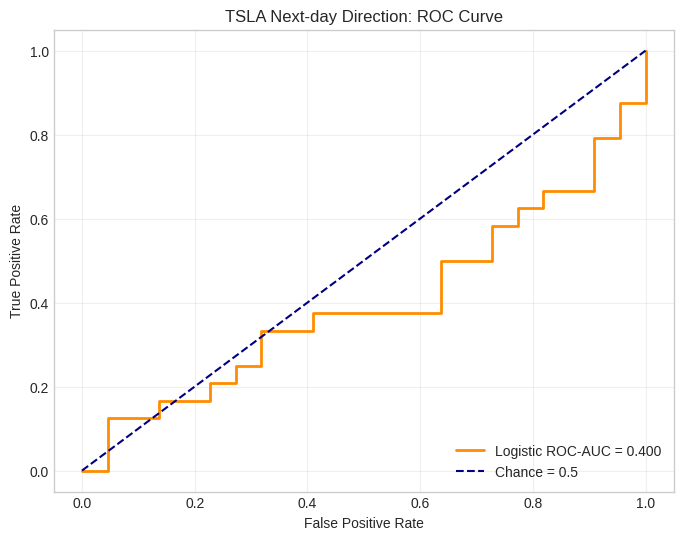

In [7]:
# ROC 커브: 테스트 구간에 상승과 비상승이 모두 있어야 계산 가능합니다.
if y_test.nunique() == 2:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_area = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Logistic ROC-AUC = {roc_area:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Chance = 0.5')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('TSLA Next-day Direction: ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print('ROC-AUC cannot be calculated: only one class occurs in the test data.')

### ROC-AUC 결과 해석

ROC-AUC는 **정해진 0.5 분류 임계값**에만 의존하지 않고, 상승일을 더 높은 확률로 평가하는지 확인합니다.

- 0.5 전후: 이 테스트 구간에서 분별력이 거의 드러나지 않음
- 1.0: 완벽한 순위 구별
- 0.5 미만: 확률의 순위가 반대 방향으로 나타난 사례일 수 있으므로 데이터와 표본을 점검

**주의:** 주식 데이터에서 특정 AUC 값(예: 0.6)을 일률적으로 유의미하다고 판단하지 않습니다. 테스트 표본 크기, 불확실성, 기준모형 및 반복 외표본 평가가 필요합니다.

### ROC-AUC와 Accuracy는 다릅니다

Accuracy는 미리 지정한 임계값(여기서는 0.5)에서의 분류 정확도를 측정합니다. ROC-AUC는 임계값을 변경했을 때의 전반적인 순위 구분 능력입니다.

두 지표는 서로 다른 정보를 주므로 함께 해석합니다. 성능이 낮게 나오더라도 현재 데이터만으로 특정 피처가 본질적으로 무효하다고 결론 내리지 않습니다.

### 결과 해석에서 지켜야 할 원칙

1. ROC-AUC가 0.5 근처라고 해서 반드시 모델 버그가 있는 것은 아닙니다.
2. 주가 방향성을 예측하기 어려운 경우, 복잡한 특징을 추가한다고 성능이 좋아지는 것은 아닙니다.
3. 테스트 데이터로 `C`, 특징, 임계값을 선택하면 **최종 외표본 평가의 독립성**이 훼손됩니다.
4. 비교가 필요하다면 검증기간(Validation)에서 선택하고 최종 테스트는 한 번만 평가해야 합니다.

### 혼동행렬(Confusion Matrix) 해석

- **TN**: 실제 비상승, 예측 비상승
- **FP**: 실제 비상승, 예측 상승
- **FN**: 실제 상승, 예측 비상승
- **TP**: 실제 상승, 예측 상승

FP가 곧 매매손실을 의미하거나 TP가 곧 실현수익을 의미하지는 않습니다. 실제 투자 결과에는 거래비용, 포지션 규칙, 진입·청산가격 등의 추가 조건이 필요합니다.

Logistic Accuracy: 0.4783
Logistic Balanced Accuracy: 0.4848
Logistic ROC-AUC: 0.3996

Out-of-sample classification benchmark:


,Model,Accuracy,Balanced Accuracy
1,Always Up,0.5217,0.5000
2,Majority Train,0.5217,0.5000
0,Logistic,0.4783,0.4848
3,Momentum,0.4565,0.4545


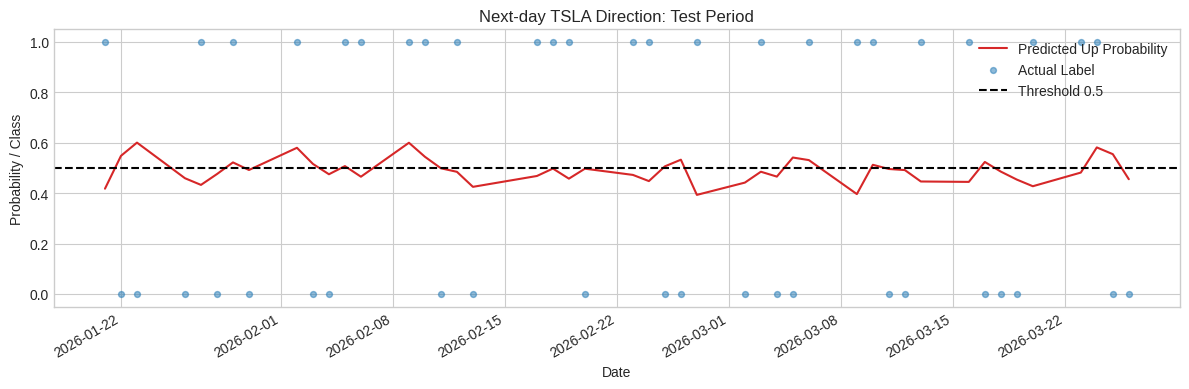

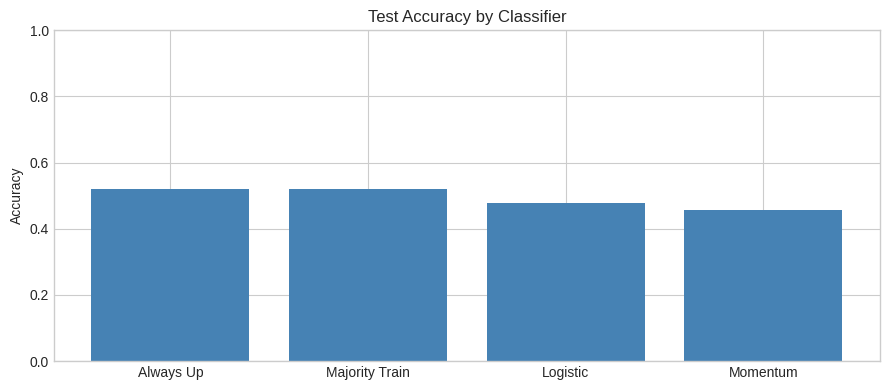

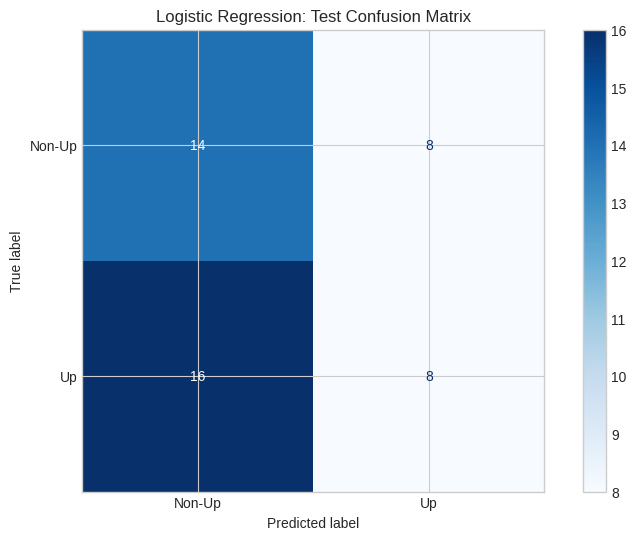

In [8]:
# 6) 테스트 구간 평가 및 시각화
# 각 기준모형은 테스트 날짜의 미래 라벨을 전혀 사용하지 않고 예측합니다.
acc = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba) if y_test.nunique() == 2 else np.nan
print(f'Logistic Accuracy: {acc:.4f}')
print(f'Logistic Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')
print(f'Logistic ROC-AUC: {auc_score:.4f}' if np.isfinite(auc_score) else 'Logistic ROC-AUC: N/A')

# 단순 분류 기준모형 (Always Up / 학습 최빈 클래스 / 당일 상승 지속)
majority_label = int(y_train.mode().iloc[0])
baselines = {
    'Logistic': np.asarray(y_pred),
    'Always Up': np.ones(len(y_test), dtype=int),
    'Majority Train': np.full(len(y_test), majority_label, dtype=int),
    'Momentum': (df.loc[X_test.index, 'ret1'].to_numpy() > 0).astype(int),
}
benchmark_rows = []
for name, pred in baselines.items():
    benchmark_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, pred)
    })
benchmark_df = pd.DataFrame(benchmark_rows).sort_values('Accuracy', ascending=False)
print('\nOut-of-sample classification benchmark:')
display(benchmark_df.round(4))

# (A) 시계열 테스트일별 예측 상승확률과 실제 라벨
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_dates, y_proba, color='tab:red', label='Predicted Up Probability')
ax.scatter(test_dates, y_test, color='tab:blue', alpha=0.5, s=18, label='Actual Label')
ax.axhline(0.5, color='black', linestyle='--', label='Threshold 0.5')
ax.set(title='Next-day TSLA Direction: Test Period', ylabel='Probability / Class', xlabel='Date')
ax.legend(loc='best'); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

# (B) 정확도 기준모형 비교
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(benchmark_df['Model'], benchmark_df['Accuracy'], color='steelblue')
ax.set(title='Test Accuracy by Classifier', ylabel='Accuracy', ylim=(0, 1))
plt.tight_layout(); plt.show()

# (C) 이진 혼동행렬: 항상 두 레이블 모두 표시
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Up', 'Up'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression: Test Confusion Matrix')
plt.show()

Test predictions (first 10 rows):


,Date,Actual,Predicted,Prob_Up,Momentum_Baseline
0,2026-01-21,1,0,0.417618,1
1,2026-01-22,0,1,0.547975,1
2,2026-01-23,0,1,0.600456,0
3,2026-01-26,0,0,0.459102,0
4,2026-01-27,1,0,0.432648,0
5,2026-01-28,0,0,0.475647,1
6,2026-01-29,1,1,0.521910,0
7,2026-01-30,0,0,0.491774,1
8,2026-02-02,1,1,0.579900,0
9,2026-02-03,0,1,0.515795,1


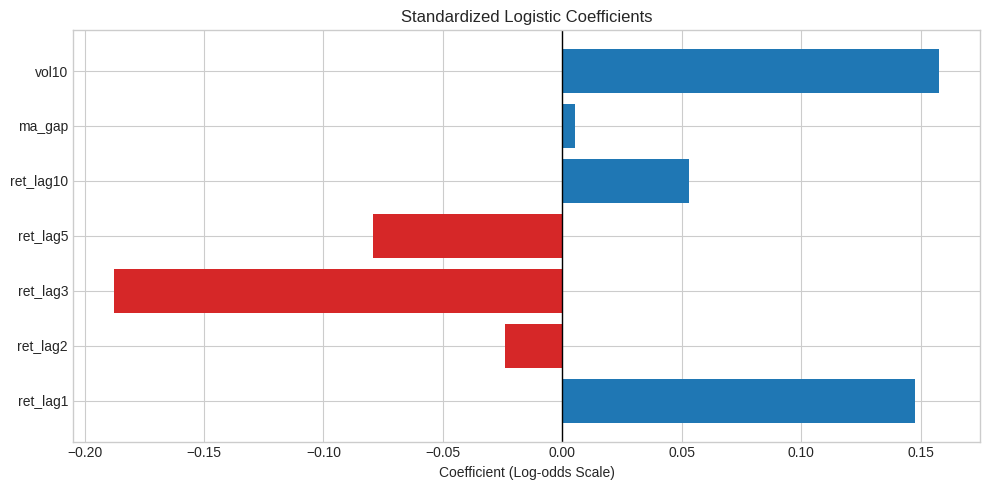

Positive coefficient: higher feature value corresponds to higher predicted log-odds, all else equal.
Coefficient is associative, not evidence of a causal effect.


In [9]:
# 7) 테스트 날짜별 분류 결과 확인 및 회귀계수 시각화
results_df = pd.DataFrame({
    'Date': test_dates.to_numpy(),
    'Actual': y_test.to_numpy(),
    'Predicted': y_pred,
    'Prob_Up': y_proba,
    'Momentum_Baseline': baselines['Momentum']
})
print('Test predictions (first 10 rows):')
display(results_df.head(10))

# 표준화된 X 기준의 회귀계수: 크기를 비교할 때 원단위가 아니라는 점에 유의
coefs = clf.named_steps['logit'].coef_[0]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(features, coefs, color=['tab:red' if c < 0 else 'tab:blue' for c in coefs])
ax.axvline(0, color='black', lw=1)
ax.set(title='Standardized Logistic Coefficients', xlabel='Coefficient (Log-odds Scale)')
plt.tight_layout(); plt.show()
print('Positive coefficient: higher feature value corresponds to higher predicted log-odds, all else equal.')
print('Coefficient is associative, not evidence of a causal effect.')

## 7) (선택) 상승·보합·하락 3분류

`y_multi`를 타깃으로 사용하면 보합 구간을 따로 구분할 수 있습니다.

- 클래스: `-1`(하락), `0`(보합), `1`(상승)
- `thr=0.002`는 강의용으로 미리 고정한 기준입니다.
- 테스트에는 새로운 임계값을 맞추지 않습니다.
- 이진분류에 사용한 `X_train`, `y_train` 등을 덮어쓰지 않도록 별도 변수로 실행합니다.
- 최근 1년간 보합 표본이 부족할 수 있으므로, 분포를 먼저 확인하세요.

In [12]:
# --- OPTIONAL: 3-class extension (uncomment to run) ---
# y_mc = df['y_multi']
# y_train_mc = y_mc.loc[X_train.index]  # 이진실습과 동일한 학습 표본 (경계 1개 제거)
# y_test_mc = y_mc.loc[X_test.index]
# print('Train class counts:', y_train_mc.value_counts().sort_index())
# if y_train_mc.nunique() < 3:
#     print('Some classes are absent: consider a longer training period.')
# else:
#     clf_mc = Pipeline(steps=[
#         ('scaler', StandardScaler()),
#         ('logit', LogisticRegression(max_iter=3000, C=1.0, random_state=42))
#     ])
#     clf_mc.fit(X_train, y_train_mc)
#     y_pred_mc = clf_mc.predict(X_test)
#     print(classification_report(y_test_mc, y_pred_mc,
#                                 labels=[-1, 0, 1], zero_division=0, digits=4))

## ✅ 요약

1. **Logistic Regression**은 다음 거래일 상승 확률을 출력하는 이진 분류기입니다.
2. 거래일 t 마감 후 t+1을 예측하므로 **특징의 이용 가능 시점**, **시간순 분할**, **학습 경계 정답 누수 방지**, **학습구간만 표준화**가 중요합니다.
3. 정확도·Balanced Accuracy·ROC-AUC·혼동행렬과 **Always Up / 학습기간 다수클래스 / Momentum 기준모형**을 함께 비교합니다.
4. 주가 예측에서의 가격 Naïve와 분류용 기준모형은 개념을 구분해서 사용합니다.

### 다음 실습 연결
Decision Tree / Random Forest 등으로 확장하되, 동일한 외표본 구간과 평가 지표를 사용해야 모델 간 비교가 가능합니다.